In [2]:
!pip install opencv-python-headless scikit-learn pandas matplotlib seaborn flask

Saving kindey stone urine analysis.csv to kindey stone urine analysis.csv
Dataset Shape: (79, 7)

First 5 Rows:


,gravity,ph,osmo,cond,urea,calc,target
0,1.021,4.91,725,14.0,443,2.45,0
1,1.017,5.74,577,20.0,296,4.49,0
2,1.008,7.20,321,14.9,101,2.36,0
3,1.011,5.51,408,12.6,224,2.15,0
4,1.005,6.52,187,7.5,91,1.16,0



Dataset Columns:
['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc', 'target']

Missing Values:
gravity    0
ph         0
osmo       0
cond       0
urea       0
calc       0
target     0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   gravity  79 non-null     float64
 1   ph       79 non-null     float64
 2   osmo     79 non-null     int64  
 3   cond     79 non-null     float64
 4   urea     79 non-null     int64  
 5   calc     79 non-null     float64
 6   target   79 non-null     int64  
dtypes: float64(4), int64(3)
memory usage: 4.4 KB
None

Class Distribution:
target
No Stone    45
Stone       34
Name: count, dtype: int64


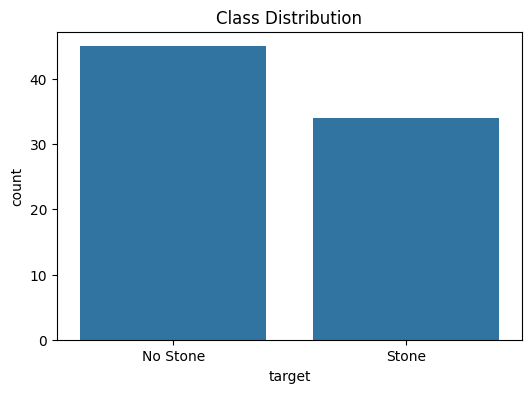

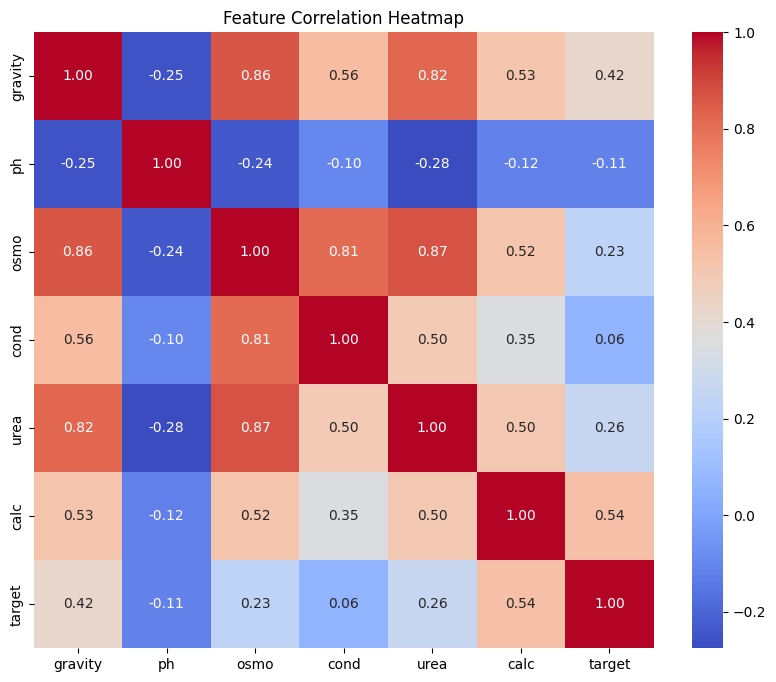

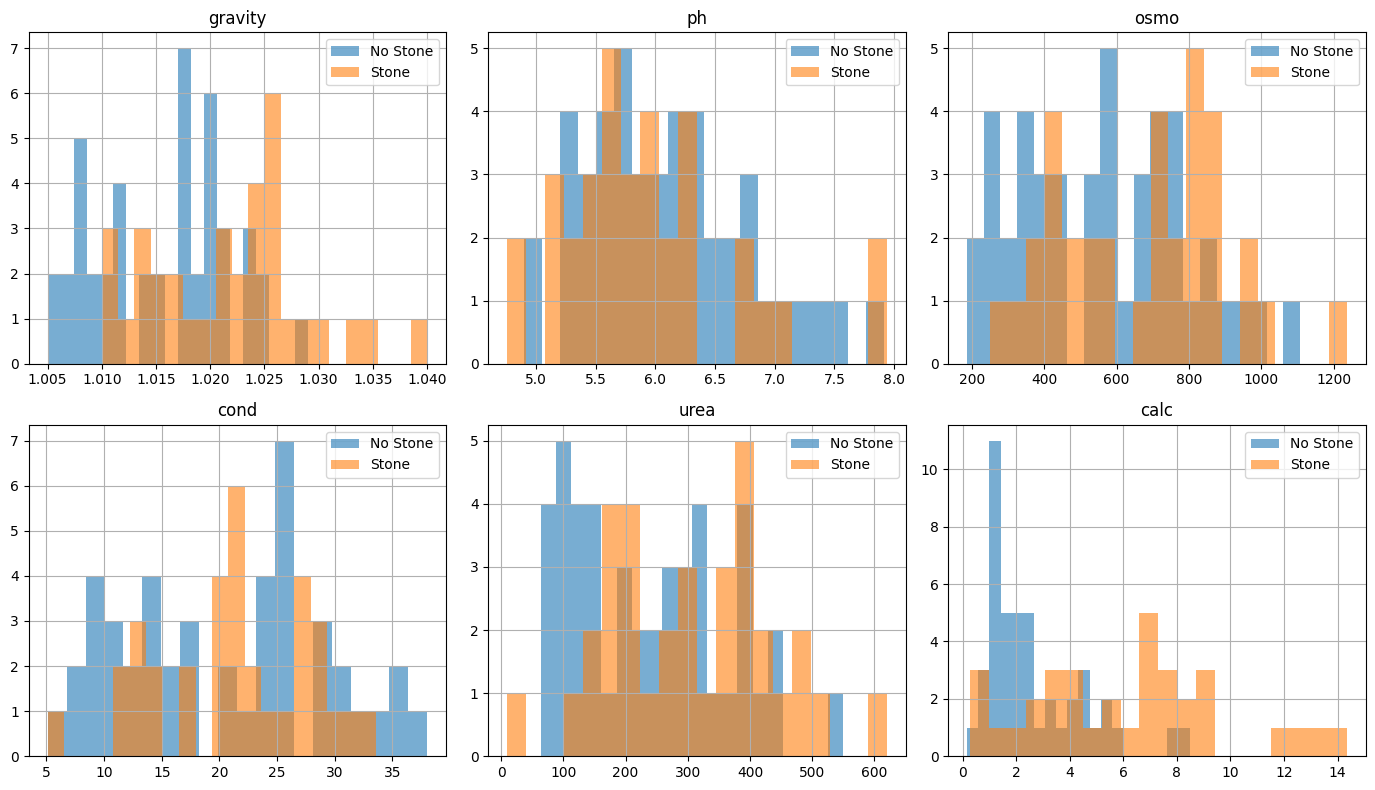

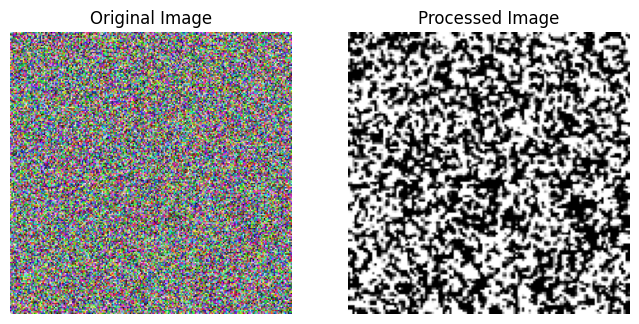

OpenCV preprocessing completed.

Base Model Accuracy: 0.75

Improved Model Accuracy: 0.6875

Classification Report:

              precision    recall  f1-score   support

    No Stone       0.75      0.67      0.71         9
       Stone       0.62      0.71      0.67         7

    accuracy                           0.69        16
   macro avg       0.69      0.69      0.69        16
weighted avg       0.70      0.69      0.69        16



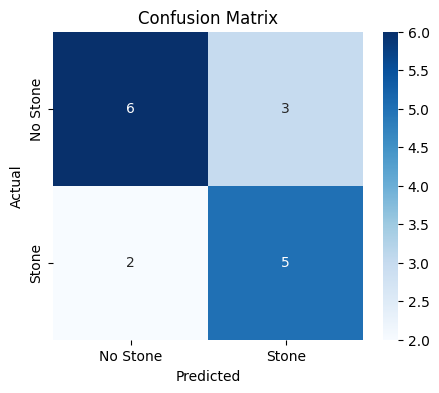

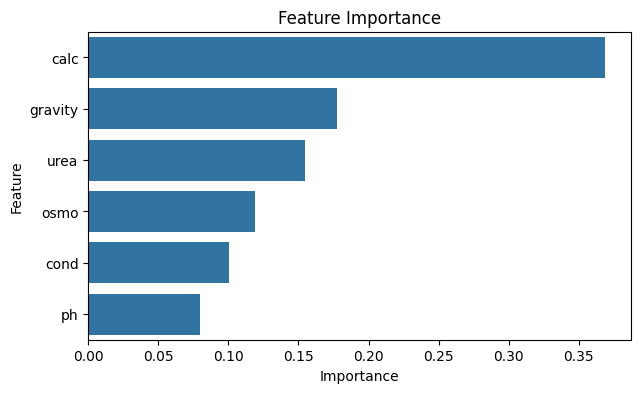


Feature Importance:
   Feature  Importance
5     calc    0.368880
0  gravity    0.177606
4     urea    0.154905
2     osmo    0.118932
3     cond    0.100188
1       ph    0.079489

--- Prediction Output ---
Input : {'gravity': 1.021, 'ph': 4.91, 'osmo': 725, 'cond': 14.0, 'urea': 443, 'calc': 2.45}
Output: {'prediction': 'No Stone Detected', 'confidence': 0.8468}

Pipeline completed successfully.


In [5]:
# ============================================================
# ML-Based Medical Diagnosis System — Kidney Stone Detection
# Skills: Python, Machine Learning, OpenCV, REST API Ready
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler

# ============================================================
# STEP 1 — Upload & Load Dataset
# ============================================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# STEP 2 — Data Overview
# ============================================================

print("\nDataset Info:")
print(df.info())

print("\nClass Distribution:")
print(df['target'].value_counts().rename({
    0: 'No Stone',
    1: 'Stone'
}))

# ============================================================
# STEP 3 — EDA
# ============================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target')
plt.xticks([0,1], ['No Stone', 'Stone'])
plt.title('Class Distribution')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature Distributions
features = ['gravity', 'ph', 'osmo', 'cond', 'urea', 'calc']

fig, axes = plt.subplots(2, 3, figsize=(14,8))

for i, col in enumerate(features):
    ax = axes[i//3][i%3]

    df[df['target']==0][col].hist(
        ax=ax,
        alpha=0.6,
        bins=20,
        label='No Stone'
    )

    df[df['target']==1][col].hist(
        ax=ax,
        alpha=0.6,
        bins=20,
        label='Stone'
    )

    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# STEP 4 — OpenCV Image Preprocessing Demo
# ============================================================

def preprocess_medical_image(image_array):

    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)

    blurred = cv2.GaussianBlur(
        gray,
        (5,5),
        0
    )

    _, thresh = cv2.threshold(
        blurred,
        127,
        255,
        cv2.THRESH_BINARY
    )

    resized = cv2.resize(
        thresh,
        (128,128)
    )

    return resized

sample_image = np.random.randint(
    0,
    256,
    (200,200,3),
    dtype=np.uint8
)

processed = preprocess_medical_image(sample_image)

fig, axes = plt.subplots(1,2, figsize=(8,4))

axes[0].imshow(sample_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(processed, cmap="gray")
axes[1].set_title("Processed Image")
axes[1].axis("off")

plt.show()

print("OpenCV preprocessing completed.")

# ============================================================
# STEP 5 — Model Training
# ============================================================

X = df[features]
y = df['target']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Base Model
base_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

base_model.fit(X_train, y_train)

base_pred = base_model.predict(X_test)

base_acc = accuracy_score(y_test, base_pred)

print("\nBase Model Accuracy:", round(base_acc,4))

# Improved Model
improved_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=3,
    class_weight='balanced',
    random_state=42
)

improved_model.fit(X_train, y_train)

y_pred = improved_model.predict(X_test)

improved_acc = accuracy_score(y_test, y_pred)

print("\nImproved Model Accuracy:", round(improved_acc,4))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No Stone', 'Stone']
    )
)

# ============================================================
# STEP 6 — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Stone','Stone'],
    yticklabels=['No Stone','Stone']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# STEP 7 — Feature Importance
# ============================================================

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': improved_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(7,4))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

print("\nFeature Importance:")
print(importance_df)

# ============================================================
# STEP 8 — Prediction Function (API Ready)
# ============================================================

def predict_kidney_stone(input_data):

    input_df = pd.DataFrame([input_data])

    input_scaled = scaler.transform(
        input_df[features]
    )

    prediction = improved_model.predict(
        input_scaled
    )[0]

    confidence = improved_model.predict_proba(
        input_scaled
    )[0][prediction]

    return {
        "prediction":
            "Stone Detected"
            if prediction == 1
            else "No Stone Detected",

        "confidence":
            round(float(confidence),4)
    }

# ============================================================
# STEP 9 — Sample Prediction
# ============================================================

sample_input = {
    'gravity': 1.021,
    'ph': 4.91,
    'osmo': 725,
    'cond': 14.0,
    'urea': 443,
    'calc': 2.45
}

result = predict_kidney_stone(sample_input)

print("\n--- Prediction Output ---")
print("Input :", sample_input)
print("Output:", result)

print("\nPipeline completed successfully.")